In [1]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses import utilities_ES as u_es
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [22]:
import pickle 
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

# with open(f'/home/mplitt/shuffle_pkls/place_field_shuff_results_spks_th.pkl','rb') as file:
#     shuff_results = pickle.load(file)
            

In [23]:
# fig, ax = plt.subplots(1,3)
max_trial = 5
x = np.arange(max_trial)


df = {'cond': [],
      'mouse': [],
      'day': [],
      'ttype': [],
      'formation_lap': [],
      'width': [],
      'argmax': [],
      'field_speed': [],
      'trial': [],
      }




for cond, mice in zip(('ko','ctrl'), (ko_mice, ctrl_mice)):
# for cond, mice in zip(('ctrl',), ( ctrl_mice,)):
    argmax_mat, formation_laps, fieldspeed_mat, width_mat = [],[], [],[]
    for mouse in mice:
        print(mouse)
        for day in range(1): 
            sess = u.load_single_day(mouse, day, verbose=False)

            for ttype in ('nov','fam'):
                
                fields_dict = shuff_results[mouse][day][ttype]


                if ttype =='fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices['spks_th'][trial_mask,:,:]
                trial_mat[np.isnan(trial_mat)]=0
                speed_mat = sess.trial_matrices['speed'][trial_mask,:]

                
                # trial_mat[trial_mat<0]=1E-5

                shifts, inds, fl, speeds, widths = stx.single_field_shifts.get_field_shifts(trial_mat, fields_dict, speed_mat,ttype)
                for s, i, f, spd, w in zip(shifts, inds, fl, speeds, widths):
                    
                    for t in range(max_trial):
                        df['cond'].append(cond)
                        df['mouse'].append(mouse)
                        df['day'].append(day)
                        df['ttype'].append(ttype)
                        df['formation_lap'].append(f)
                        df['width'].append(w)
                        df['trial'].append(t)

                        df[f'argmax'].append(s[t])
                        df[f'field_speed'].append(spd[t])
                

df = pd.DataFrame.from_dict(df)

4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


4467975.4
4467975.5
Cre7
Cre9
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9


3.179759565454783 0.0014739729508625424


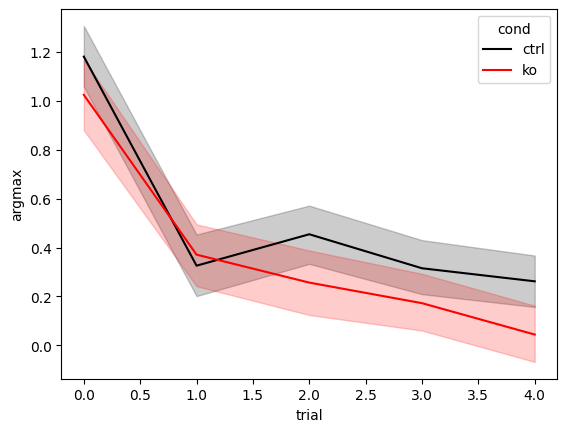

In [24]:
mask = (df['day']==0) * (df['ttype']=='nov') #*(df['field_speed']>15) # *(df['field_speed']<50)
ax = sns.lineplot(
    data = df.loc[mask,:],
    x='trial',
    y = 'argmax',
    hue = 'cond',
    hue_order = ['ctrl', 'ko'],
    palette=['black','red'],
    estimator='mean',
    errorbar='ci',
)


# df_tmp = df.loc[mask,:].groupby(['mouse','trial','cond','ttype']).mean().reset_index()
# mask = (df_tmp['day']==0) * (df_tmp['ttype']=='nov') 
t, p = sp.stats.ranksums(df.loc[mask*(df['cond']=='ctrl'),'argmax'],
                         df.loc[mask*(df['cond']=='ko'), 'argmax'])
print(t,p)




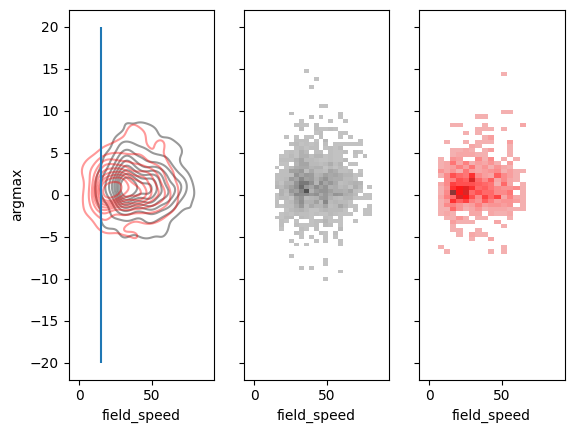

In [25]:
fig, ax = plt.subplots(1,3, sharey=True,sharex=True)
mask = (df['day']==0) * (df['ttype']=='nov') * (df['trial']==0)
sns.kdeplot(
    data=df.loc[mask*df['cond']=='ctrl',:],
    x='field_speed',
    y='argmax',
    color='black',
    alpha=.4,
    ax=ax[0]

)
sns.histplot(
    data=df.loc[mask*df['cond']=='ctrl',:],
    x='field_speed',
    y='argmax',
    color='black',
    ax=ax[1]

)

sns.kdeplot(
    data=df.loc[mask*df['cond']=='ko',:],
    x='field_speed',
    y='argmax',
    color='red',
    ax=ax[0],
    alpha=.4
)

sns.histplot(
    data=df.loc[mask*df['cond']=='ko',:],
    x='field_speed',
    y='argmax',
    color='red',
    ax=ax[2],

)

ax[0].vlines([15,],-20,20)

In [18]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)


# with open(f'/home/mplitt/shuffle_pkls/sparse_place_field_shuff_results_F_dff.pkl','rb') as file:
#     shuff_results = pickle.load(file)
            

In [19]:

x = np.arange(max_trial)


argmax_dict = {}
# argmax_mat, formation_laps, fieldspeed_mat, width_mat = [],[], [],[]
for mouse in sparse_mice:
    argmax_dict[mouse] = {}
    for day in range(2): 
        argmax_dict[mouse][day]={}
        sess = u.load_single_day(mouse, day, pkl_basedir='/home/mplitt/YMazeSessPkls')
        for ttype in ('nov',):
            argmax_dict[mouse][day][ttype] = {}
            
            for chan in ('channel_0', 'channel_1'):
            
                fields_dict = shuff_results[mouse][chan][day][ttype]


                if ttype =='fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices[f'{chan}_F_dff'][trial_mask,:,:]
                speed_mat = sess.trial_matrices['speed'][trial_mask,:]


                trial_mat[np.isnan(trial_mat)]=0
                # trial_mat[trial_mat<=0]=1E-5
            


                shifts, inds, fl, speeds, widths= stx.single_field_shifts.get_field_shifts(trial_mat, fields_dict, speed_mat,ttype)
                print(len(shifts))
                argmax_dict[mouse][day][ttype][chan] = stx.single_field_shifts.shifts_to_matrix(shifts, max_trial).mean(axis=0)[np.newaxis,:]
            # print(argmax_mat)

            # if cond == 'ko':
            #     ax.plot(x, argmax_mat.mean(axis=0), color='red')
            # else:
            #     ax.plot(x, argmax_mat.mean(axis=0), color='black')



{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
2
1
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
7
4
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
11
2
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2}
16
4
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 11, 'novel_arm': -1, 'exp_day': 1}
16
13
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 26, 'novel_arm': -1, 'exp_day': 2}
12
15
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 17, 'novel_arm': 1, 'exp_day': 1}
15
8
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 7, 'scan': 19, 'novel_arm': 1, 'exp_day': 2}
14
17
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 1}
6
2
{'date': '30_05_

In [20]:
argmax_dict[mouse][day]['nov']['channel_1']
    # chan1_mu.append(argmax_dict[mouse][day]['nov']['channel_1'])

array([[0.40683761, 0.24017094, 0.40683761, 0.07350427, 0.74017094]])

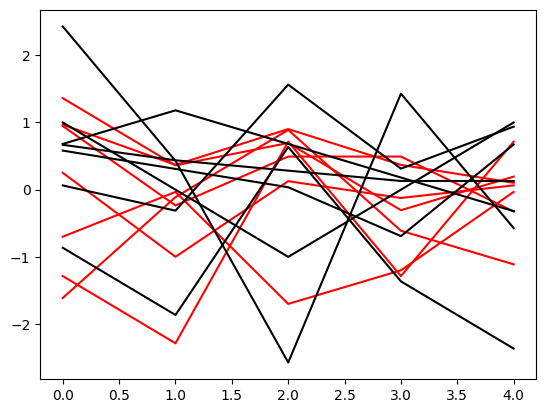

In [21]:
fig, ax = plt.subplots()
day=0
chan0_mu, chan1_mu = [], []
for mouse in sparse_mice:
    chan0_mu.append(argmax_dict[mouse][day]['nov']['channel_0'])
    chan1_mu.append(argmax_dict[mouse][day]['nov']['channel_1'])
chan0_mu, chan1_mu = np.squeeze(np.array(chan0_mu)), np.squeeze(np.array(chan1_mu))

ax.plot(x, chan0_mu.T, color='red')
ax.plot(x, chan1_mu.T, color='black')


-1.6111111111111112 1.0
0.9473068598068598 -0.8645833333333335
0.2514192130968447 0.6678950828748399
0.9685721359250772 0.06308210784313717
-0.6998108425074717 0.6807740324594257
1.3615701836290075 0.581558229352347
-1.2857142857142856 2.4285714285714284


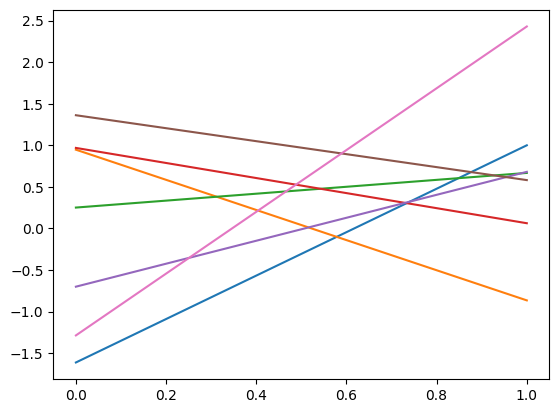

In [22]:
fig,ax=plt.subplots()
for ch0, ch1 in zip(chan0_mu[:,0], chan1_mu[:,0]):
    print(ch0, ch1)
    ax.plot([0,1], [ch0,ch1])

In [42]:
sp.stats.wilcoxon(chan0_mu[:,0]-chan1_mu[:,0])

WilcoxonResult(statistic=np.float64(4.0), pvalue=np.float64(0.109375))